# Free-Vibration (Modal) Analysis

`BeamAnalysis.modal()` returns the natural frequencies and mode shapes of a beam. It assembles a **consistent mass matrix** alongside the stiffness matrix and solves the generalized eigenproblem

$$ \mathbf{K}\,\boldsymbol\phi = \omega^2\,\mathbf{M}\,\boldsymbol\phi, $$

refining each span into several Euler–Bernoulli sub-elements so the higher modes are captured accurately. Supply the **mass per unit length** (consistent units with `EI`); supports — including elastic springs — are taken from the beam, and the analysis is independent of any applied loads.

Supported for prismatic, fixed-fixed spans without shear flexibility (`GAv`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pycba as cba

## Validation: a simply-supported beam

For a prismatic simply-supported beam the natural circular frequencies are

$$ \omega_n = \left(\frac{n\pi}{L}\right)^2 \sqrt{\frac{EI}{\bar m}}. $$

 mode   omega (PyCBA)   omega (exact)
   1        0.09870       0.09870
   2        0.39480       0.39478
   3        0.88850       0.88826
   4        1.58042       1.57914


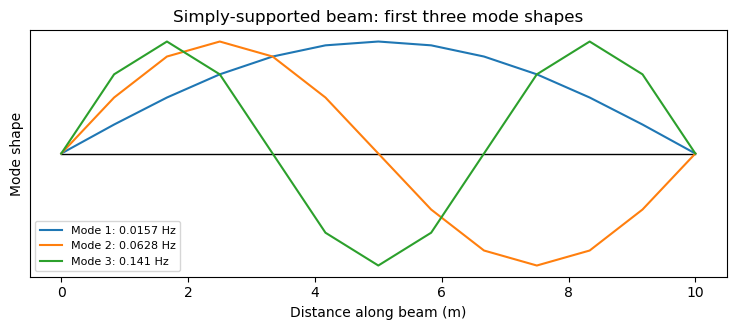

In [2]:
L, EI, m = 10.0, 1.0, 1.0   # length, EI, mass/length (consistent units)

modal = cba.BeamAnalysis([L], EI, [-1, 0, -1, 0]).modal(mass=m, n_modes=4)
exact = np.array([(n * np.pi / L) ** 2 * np.sqrt(EI / m) for n in (1, 2, 3, 4)])

print(" mode   omega (PyCBA)   omega (exact)")
for i, (w, e) in enumerate(zip(modal.omega, exact), start=1):
    print(f"   {i}      {w:9.5f}     {e:9.5f}")

modal.plot(modes=[0, 1, 2])
plt.title("Simply-supported beam: first three mode shapes")
plt.show()

## A continuous bridge beam

A two-span continuous beam, in SI units (N, m, kg), as for a pedestrian/traffic vibration check. `modal()` returns `omega` (rad/s), `f` (Hz) and the natural `periods` (s).

mode 1:  f =  1.113 Hz   (T = 0.899 s)
mode 2:  f =  1.738 Hz   (T = 0.575 s)
mode 3:  f =  4.451 Hz   (T = 0.225 s)
mode 4:  f =  5.633 Hz   (T = 0.178 s)


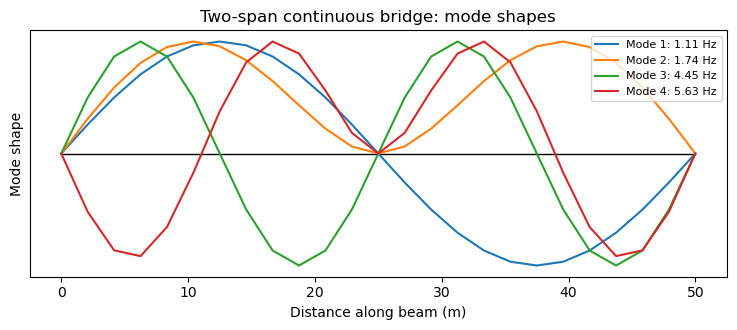

In [3]:
E = 2.1e11           # Pa (steel)
I = 1.4e-3           # m^4
EI = E * I
mbar = 1500.0        # kg/m (girder + deck)
spans = [25.0, 25.0]

bridge = cba.BeamAnalysis(spans, EI, [-1, 0, -1, 0, -1, 0])
modal = bridge.modal(mass=mbar, n_modes=4)

for i in range(modal.n_modes):
    print(f"mode {i+1}:  f = {modal.f[i]:6.3f} Hz   (T = {modal.periods[i]:.3f} s)")

modal.plot(modes=[0, 1, 2, 3])
plt.title("Two-span continuous bridge: mode shapes")
plt.show()

## Notes

- The mass is a mass per unit length, in units consistent with `EI` (e.g. kg/m with `EI` in N·m², giving frequencies in Hz).
- Accuracy improves with the refined mesh (`nseg` per span, default 12); the first several modes are already well within 1% of the analytic values.
- Current support: prismatic, fixed-fixed spans without shear flexibility (`GAv`). Elastic spring supports are included in the stiffness; other combinations raise a clear `NotImplementedError`.